In [2]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
# 1. Set size
sample_size = 100000  # Large size for robust training

# 2. Generate inputs manually within your exact range [1, 100)
a = (torch.rand(sample_size) * 999) + 1
b = (torch.rand(sample_size) * 999) + 1

# 3. Add Gaussian noise with identical dimensions
noise = torch.randn(sample_size) * 0.1

# 4. Calculate robust targets: -(a + b) + noise
y_real = -(a + b) + noise

In [ ]:
lr = 0.000001

max_iter = 100000

In [ ]:
i = 0
# Initialising Weights
w1 = torch.rand((), requires_grad=True)
w2 = torch.rand((), requires_grad=True)

# Set initial loss as a float instead of a PyTorch Tensor
loss_val = float("inf")


while loss_val > 0.011:
    if i >= max_iter:
        print("Maximum iterations reached")
        print("Trained Condition Could not be closely satisfied")
        print(f"Final loss = {loss_val}")
        break

    # Forward
    y_pred = (a * w1) + (b * w2)

    # Loss
    loss = ((y_pred - y_real) ** 2).mean()
    loss_val = loss.item()  # Extract python float for loop check

    # Backward
    loss.backward()

    # Update weights
    with torch.no_grad():  # Dont Calculate gradients during this time
        w1 -= lr * w1.grad
        w2 -= lr * w2.grad

        w1.grad = None
        w2.grad = None

    i += 1
else:
    print(f"Model trained Success fully in {i} iterations")
    print(f"Final Loss : {loss_val}")

Model trained Success fully in 884 iterations
Final Loss : 0.010745440609753132


In [20]:
def sumt(a, b):
    return round(((a * w1) + (b * w2)).item())

sumt(100, 2791)

-2871

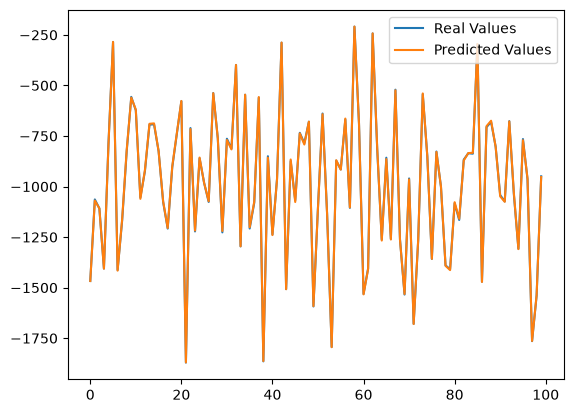

In [21]:
samples = range(sample_size)

sns.lineplot(
    x = samples,
    y = y_real.numpy(),
    label = "Real Values"
)
sns.lineplot(
    x = samples,
    y = y_pred.detach().numpy(),
    label = "Predicted Values"
)

plt.show()